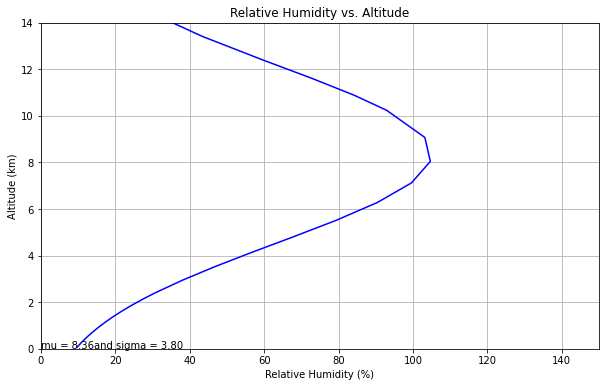

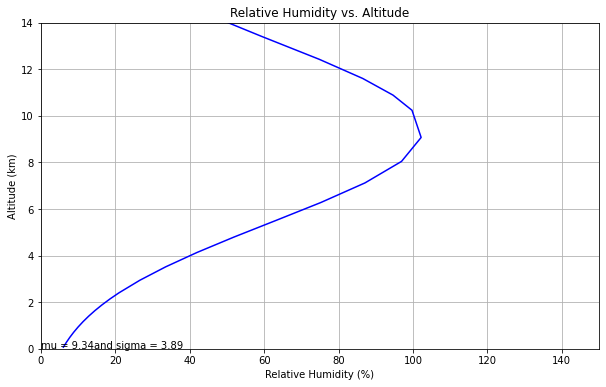

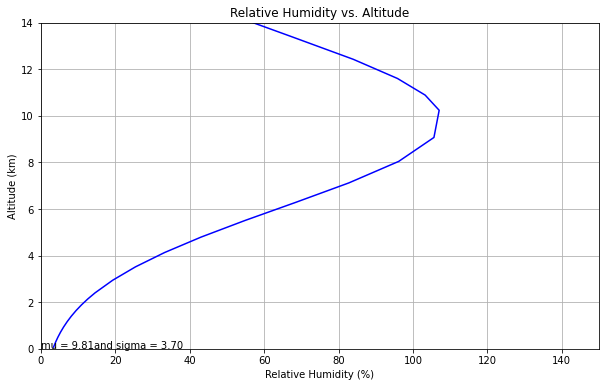

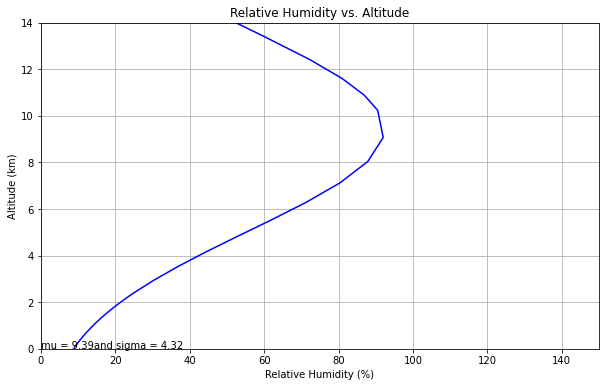

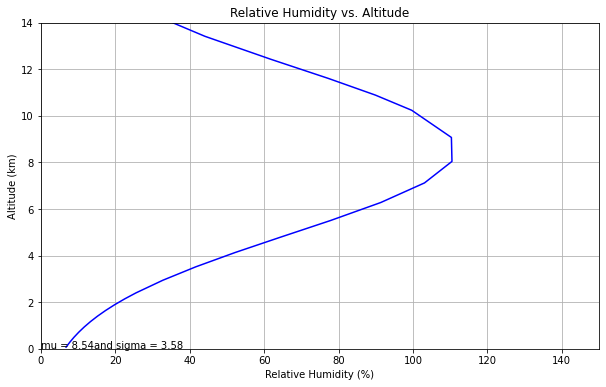

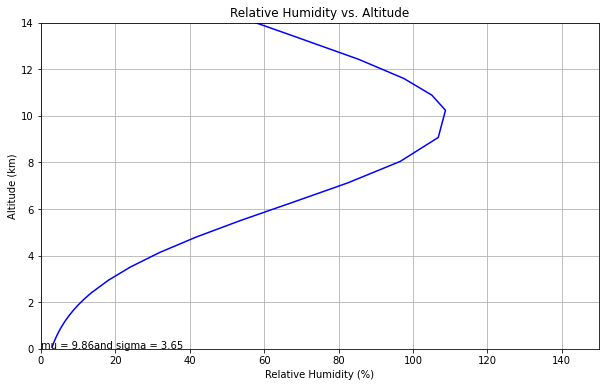

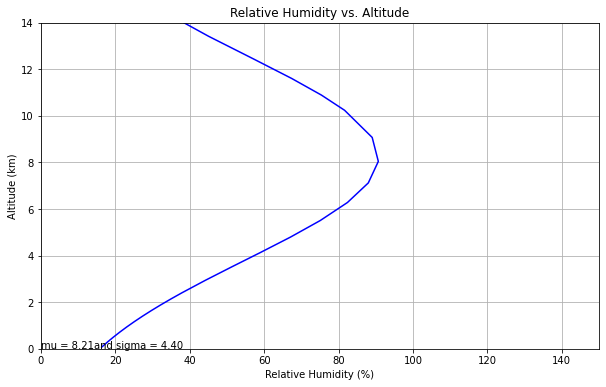

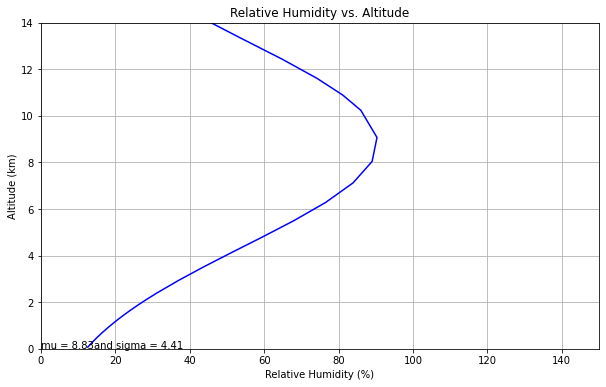

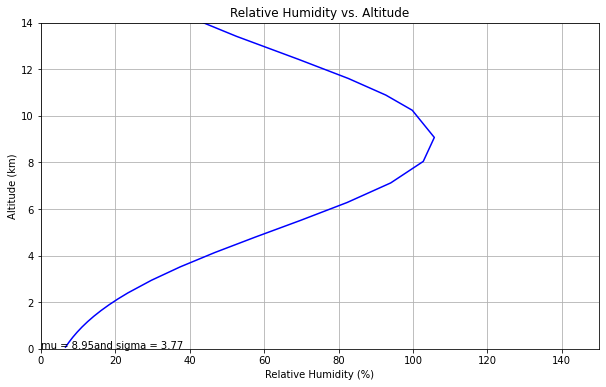

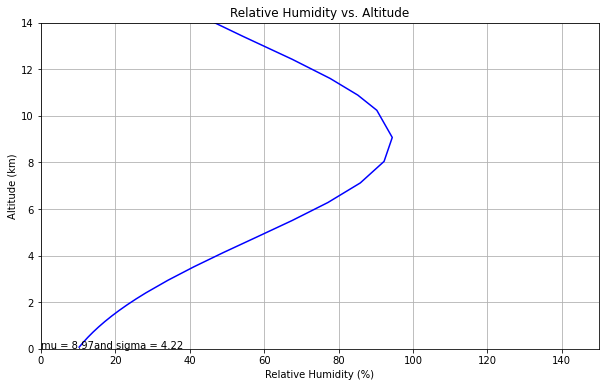

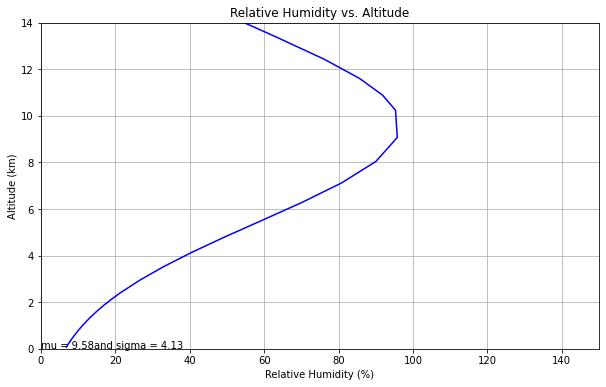

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import shutil
import xarray as xr
import time

class RH_profile:
    def __init__(self, mu, sigma, altitudes, RH):
        self.mu = mu # mean
        self.sigma = sigma # std
        self.altitudes = altitudes
        self.RH = RH

test_num = 100
j = 0
cases = []

altitude = [0.0706847161054611, 0.280354559421539, 0.494257032871246, 
    0.71270889043808, 0.936570823192596, 1.16609489917755, 1.40123450756073, 
    1.64200806617737, 1.88862943649292, 2.14136052131653, 2.40070509910583, 
    2.94195675849915, 3.51732301712036, 4.13245820999146, 4.79369401931763, 
    5.50710439682007, 6.27960538864136, 7.12048578262329, 8.04355049133301, 
    9.07177543640137, 10.2383241653442, 10.8901128768921, 11.6034088134766, 
    12.4268131256104, 13.4131603240967, 14.5604238510132, 15.9659404754639, 
    18.1929683685303, 20.2443885803223, 23.3482246398926, 25.7990627288818, 
    30.0542526245117, 32.3974838256836, 34.8223838806152, 38.9491233825684, 
    42.2613258361816, 47.5921516418457]

mu_lower_bound = 8
mu_upper_bound = 10
sigma_lower_bound = 0
sigma_upper_bound = 8

for j in range(test_num):
    # Sample data
    mu = random.uniform(mu_lower_bound, mu_upper_bound)
    sigma = random.uniform(sigma_lower_bound, sigma_upper_bound)
    humidity = np.zeros_like(altitude)

    for i in range(len(altitude)):
        humidity[i] = (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((altitude[i] - mu)/sigma)**2) * 1000
    
    if any(value > 90 for value in humidity) & (any(value > 120 for value in humidity) == False):
        # Create the plot
        plt.figure(figsize=(10, 6))
        plt.plot(humidity, altitude, linestyle='-', color='b')
        plt.xlim(0,150)
        plt.ylim(0,14)
        plt.ylabel('Altitude (km)')
        plt.xlabel('Relative Humidity (%)')
        plt.title('Relative Humidity vs. Altitude')
        plt.grid(True)
        plt.text(0,0,"mu = " + str(f"{mu:.2f}") + "and sigma = " + str(f"{sigma:.2f}"))
        plt.savefig("/home/chinahg/GCresearch/contrailuncertainty/randomRH_plots/mu" + str(f"{mu:.2f}") + "sigma" + str(f"{sigma:.2f}") + ".png")
        plt.show()

        # Save data
        cases.append(RH_profile(mu,sigma,altitude,humidity))

In [6]:
# Import new profile to APCEMM met file
# Open the NetCDF file for writing

for i in range(len(cases)): # iterate through tests
    # Create new met file to edit with RH data
    met_name = "mu" + str(f"{cases[i].mu:.2f}") + "sigma" + str(f"{cases[i].sigma:.2f}")

    dest_dir = '/home/chinahg/GCresearch/contrailuncertainty/APCEMM_results'
    src_file = '/home/chinahg/GCresearch/APCEMM/examples/Example3_met_input/example_met_file.nc'
    shutil.copy(src_file,dest_dir) #copy the file to destination dir

    dst_file = os.path.join(dest_dir,'example_met_file.nc')
    new_dst_file_name = os.path.join(dest_dir, met_name + 'met.nc')
    # os.rename(dst_file, new_dst_file_name) #rename

    # Edit nc file with RH profiles
    nc_file = xr.open_dataset(src_file)

    # Modify its values
    #print(nc_file['relative_humidity'][:])
    nc_file['relative_humidity'][:] = cases[i].RH
    #print("New values for case " + str(i))
    #print(nc_file['relative_humidity'][:])
    
    # Close the NetCDF file to save changes
    nc_file.to_netcdf(new_dst_file_name)
    nc_file.close()

    # Modify input.yaml file to take new meteorological netCDF file (changes saved but overwritten later)
    import yaml

    # Load the YAML file
    with open("/home/chinahg/GCresearch/APCEMM/examples/Example3_met_input/input.yaml", "r") as file:
        data = yaml.safe_load(file)

    # Modify the desired line
    data["METEOROLOGY MENU"]["METEOROLOGICAL INPUT SUBMENU"]["Met input file path (string)"] = new_dst_file_name

    # Save the modified data back to the YAML file
    with open("/home/chinahg/GCresearch/APCEMM/examples/Example3_met_input/input.yaml", "w") as file:
        yaml.dump(data, file, default_flow_style=False)

    # Then, run APCEMM with modified netCDF input file (see example 3)
    !sbatch /home/chinahg/GCresearch/APCEMM/rundirs/SampleRunDir/uncertainty.sh

Submitted batch job 352996
1 minute(s) have passed, continuing...
Submitted batch job 352997
1 minute(s) have passed, continuing...


In [1]:
!ncdump /home/chinahg/GCresearch/APCEMM/examples/Example3_met_input/example_met_file.nc

netcdf example_met_file {
dimensions:
	altitude = 37 ;
	time = 24 ;
variables:
	double altitude(altitude) ;
		altitude:units = "km" ;
	double time(time) ;
		time:units = "s" ;
	double var_length ;
		var_length:units = "-" ;
	double pressure(altitude) ;
		pressure:units = "hPa" ;
	double temperature(altitude, time) ;
		temperature:units = "K" ;
	double relative_humidity(altitude) ;
		relative_humidity:units = "Pct" ;
	double relative_humidity_ice(altitude) ;
		relative_humidity_ice:units = "Pct" ;
	double shear(altitude, time) ;
		shear:units = "s^-1" ;
	double flight_altitude ;
		flight_altitude:units = "hPa" ;
	double soot_emission_index ;
		soot_emission_index:units = "g/kg" ;
	double soot_radius ;
		soot_radius:units = "m" ;
	double fuel_flow_rate ;
		fuel_flow_rate:units = "kg/s" ;
	double aircraft_mass ;
		aircraft_mass:units = "kg" ;
	double flight_velocity ;
		flight_velocity:units = "m/s" ;
	double number_engines ;
		number_engines:units = "-" ;
	double wingspan ;
		wingspan:un